In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
decode_lab_internship_w3 = pd.read_excel(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\DECODE LABS\Week_3_files\Dataset for Data Analytics.xlsx")
decode_lab_internship_w3.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# UNDERSTANDING THE DATASET STRUCTURE


In [2]:
decode_lab_internship_w3.shape

(1200, 14)

In [3]:
decode_lab_internship_w3.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [4]:
decode_lab_internship_w3.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [5]:
decode_lab_internship_w3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


This dataset contains business and sales transaction data having 1200 rows and 14 columns.
The dataset includes:
- Customer information
- Product details
- Order transactions
- Pricing data
- Payment methods
- Order statuses

The dataset can be used for:
- Sales analysis
- Customer behavior analysis
- Business insights
- Revenue prediction
- Machine learning prediction tasks

# DATA CLEANING & PREPROCESSING

In [6]:
decode_lab_internship_w3.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [7]:
numeric_cols = decode_lab_internship_w3.select_dtypes(include=np.number).columns
for col in numeric_cols:
    decode_lab_internship_w3[col] = decode_lab_internship_w3[col].fillna(
        decode_lab_internship_w3[col].mean()
    )
categorical_cols = decode_lab_internship_w3.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    decode_lab_internship_w3[col].fillna(
        decode_lab_internship_w3[col].mode()[0]
    )

before_duplicates = decode_lab_internship_w3.shape[0]
decode_lab_internship_w3.drop_duplicates(inplace=True)

after_duplicates = decode_lab_internship_w3.shape[0]
after_duplicates
if 'Date' in decode_lab_internship_w3.columns:
    decode_lab_internship_w3['Date'] = pd.to_datetime(
        decode_lab_internship_w3['Date']
    )
    decode_lab_internship_w3.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [8]:
decode_lab_internship_w3.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


# IDENTIFYING DATASET TRENDS

In [9]:
numeric_cols

Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice'], dtype='str')

In [10]:
correlation = decode_lab_internship_w3[numeric_cols].corr()
correlation

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


In [11]:
if 'TotalPrice' in decode_lab_internship_w3.columns:

    Q1 = decode_lab_internship_w3['TotalPrice'].quantile(0.25)
    Q3 = decode_lab_internship_w3['TotalPrice'].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = decode_lab_internship_w3[
        (decode_lab_internship_w3['TotalPrice'] < lower_bound) |
        (decode_lab_internship_w3['TotalPrice'] > upper_bound)
    ]
    outliers.shape

 # DATASET VISUALIZATION

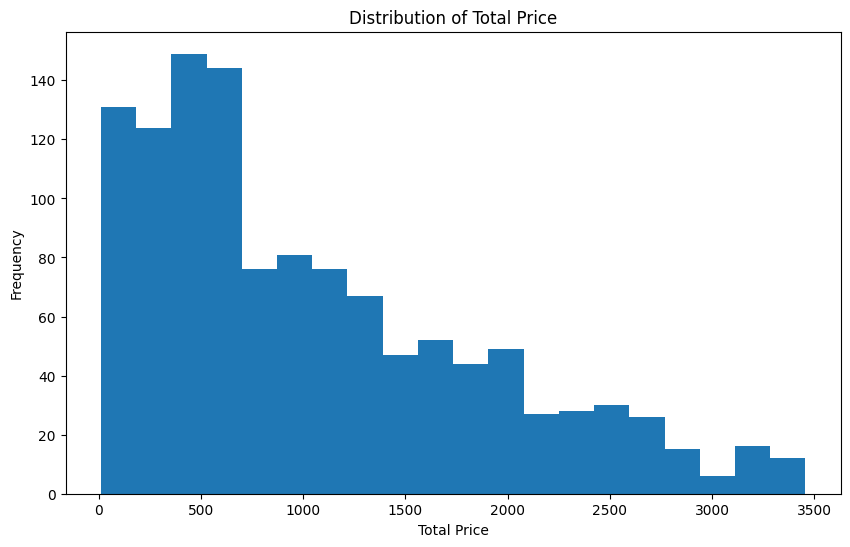

In [12]:
if 'TotalPrice' in decode_lab_internship_w3.columns:

    plt.figure(figsize=(10,6))
    plt.hist(decode_lab_internship_w3['TotalPrice'],bins=20)
    plt.title('Distribution of Total Price')
    plt.xlabel('Total Price')
    plt.ylabel('Frequency')
    plt.show()

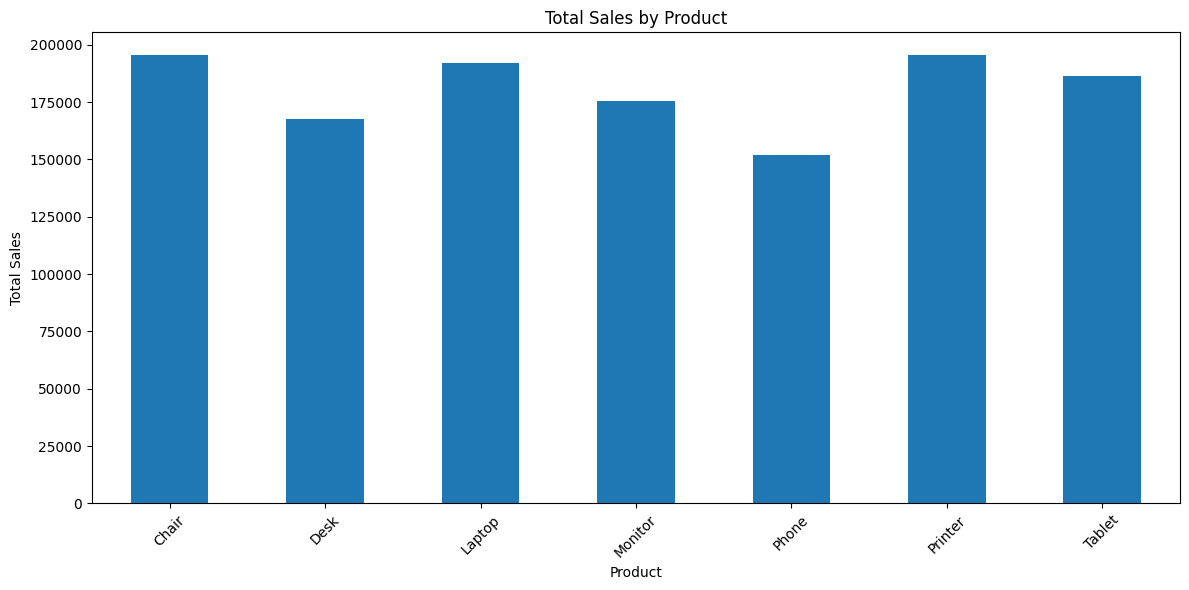

In [13]:
if 'Product' in decode_lab_internship_w3.columns:
    product_sales = decode_lab_internship_w3.groupby('Product')['TotalPrice'].sum()
    plt.figure(figsize=(12,6))
    product_sales.plot(kind='bar')
    plt.title('Total Sales by Product')
    plt.xlabel('Product')
    plt.ylabel('Total Sales')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


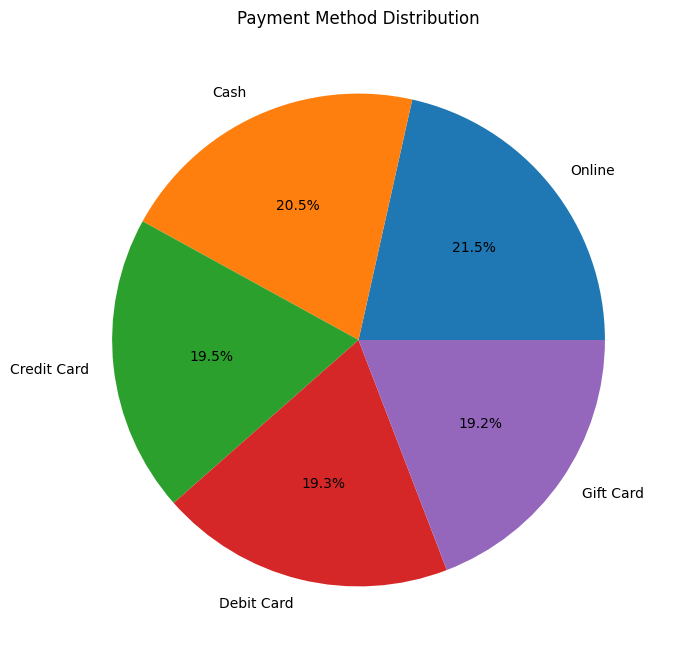

In [14]:
if 'PaymentMethod' in decode_lab_internship_w3.columns:
    payment_counts = decode_lab_internship_w3['PaymentMethod'].value_counts()
    plt.figure(figsize=(8,8))
    payment_counts.plot(kind='pie',autopct='%1.1f%%')
    plt.title('Payment Method Distribution')
    plt.ylabel('')
    plt.show()


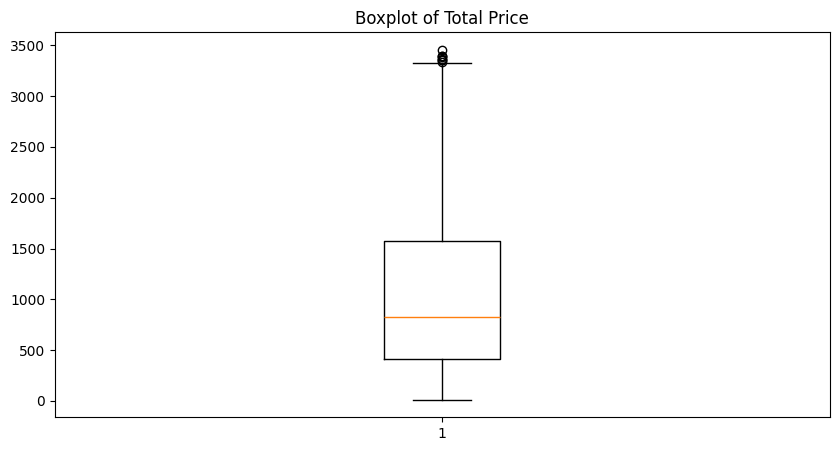

In [15]:
if 'TotalPrice' in decode_lab_internship_w3.columns:
    plt.figure(figsize=(10,5))
    plt.boxplot(decode_lab_internship_w3['TotalPrice'])
    plt.title('Boxplot of Total Price')
    plt.show()

# MACHINE LEARNING MODEL

In [16]:
possible_features = []

for col in ['Quantity', 'UnitPrice', 'ItemsInCart']:
    if col in decode_lab_internship_w3.columns:
        possible_features.append(col)

target = 'TotalPrice'

if target in decode_lab_internship_w3.columns:

    X = decode_lab_internship_w3[possible_features]
    y = decode_lab_internship_w3[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print("MAE:", mae)
    print("R2:", r2)

MAE: 211.52582150138193
R2: 0.8904918215121347


In [17]:
# This demonstrates how the model can predict future sales values.
features = possible_features
sample_data = [[5, 200, 2]]
sample_df = pd.DataFrame(sample_data, columns=features)
sample_prediction = model.predict(sample_df)
sample_prediction

array([1313.07672667])

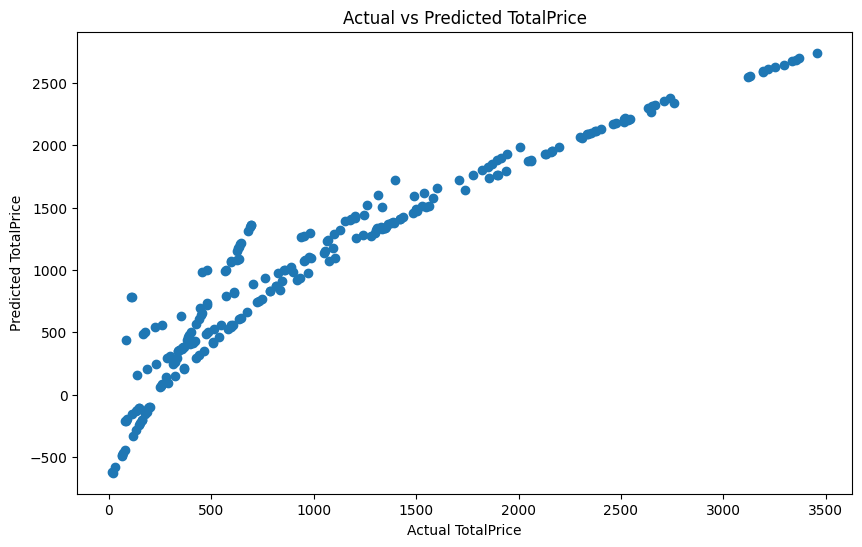

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual TotalPrice")
plt.ylabel("Predicted TotalPrice")
plt.title("Actual vs Predicted TotalPrice")
plt.show()

In [19]:
#The analysis showed that Quantity and UnitPrice are the strongest drivers of TotalPrice. Customer payment behavior and referral sources also revealed important business trends. A Linear Regression model was successfully developed to predict TotalPrice with good accuracy, demonstrating the practical application of machine learning in business analytics.